# Predicted vs Real Profiles — Several Process Executions

Loads the saved curve arrays (`predicted_curves.parquet`, written when a run has
`save_predicted_curves: True` in `pipeline.py`) directly from disk — no retraining,
these are the actual production models' outputs. For a chosen process and a handful of
sensors, plots the real complete-case profile against every approach available for that
sensor, for several real test cases ("process executions"):

- **Real** — the case's actual sensor readings.
- **Best, mine** — full process simulation (best-fidelity mode) + DTW + Ext. Factors +
  Prev. Activity curve prediction.
- **Schedule-direct** — case-level regression from schedule-only features, no simulation.
- **Stochastic generator** — per-position Normal fit, no conditioning at all.

Source: `schedule_profile_eval_results/<process>/predicted_curves.parquet` (requires the
pipeline run to have `run_schedule_profile_eval: True` and `save_predicted_curves: True`).


In [1]:
# -- Config --------------------------------------------------------------------
PROCESS = 'process_1'
N_CASES = 4          # how many real test cases to show per sensor
SENSORS = None       # None = auto-pick sensors that have all 4 series (real/best/schedule/stochastic);
                     # or set explicitly, e.g. ['destillation_steam_demand_kW_energy_to_model']
RANDOM_STATE = 42


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 50)

results_root = Path('..') / 'results'
# Pick the latest run that actually has schedule_profile_eval_results with predicted curves.
_candidates = []
for d in sorted(results_root.iterdir()):
    if not d.is_dir():
        continue
    f = d / 'schedule_profile_eval_results' / PROCESS / 'predicted_curves.parquet'
    if f.exists():
        _candidates.append(d)
assert _candidates, f'No run found with schedule_profile_eval_results/{PROCESS}/predicted_curves.parquet'
run_dir = _candidates[-1]
print(f'Using run: {run_dir.name}')

curves_path = run_dir / 'schedule_profile_eval_results' / PROCESS / 'predicted_curves.parquet'
df_curves = pd.read_parquet(curves_path)
print(f'{len(df_curves)} rows | sensors: {sorted(df_curves["sensor"].unique())} | '
      f'{df_curves["case_id"].nunique()} cases | series: {sorted(df_curves["series"].unique())}')


Using run: experiment_905_20260713_190136
245564 rows | sensors: ['autoclave_cooling_water_demand_kW_energy_to_model', 'autoclave_steam_demand_kW_energy_to_model', 'bottling_power_kW_energy_to_model', 'destillation_cooling_demand_kW_energy_to_model', 'destillation_steam_demand_kW_energy_to_model', 'individual_packaging_power_kW_energy_to_model', 'water_supply_power_kW_energy_to_model'] | 90 cases | series: ['best', 'real', 'schedule', 'stochastic']


In [3]:
# -- Pick sensors and cases to show --
_series_by_sensor = df_curves.groupby('sensor')['series'].apply(set)
if SENSORS is None:
    _full_coverage = [s for s, ser in _series_by_sensor.items() if {'real', 'best', 'schedule', 'stochastic'} <= ser]
    SENSORS = _full_coverage if _full_coverage else sorted(df_curves['sensor'].unique())
print(f'Sensors to show: {SENSORS}')
for s in SENSORS:
    print(f'  [{s}] series available: {sorted(_series_by_sensor.get(s, set()))}')

rng = np.random.default_rng(RANDOM_STATE)
_all_cases = sorted(df_curves['case_id'].unique())
example_cases = list(rng.choice(_all_cases, size=min(N_CASES, len(_all_cases)), replace=False))
print(f'Example cases (process executions): {example_cases}')


Sensors to show: ['autoclave_cooling_water_demand_kW_energy_to_model', 'autoclave_steam_demand_kW_energy_to_model', 'bottling_power_kW_energy_to_model', 'destillation_cooling_demand_kW_energy_to_model', 'destillation_steam_demand_kW_energy_to_model', 'individual_packaging_power_kW_energy_to_model']
  [autoclave_cooling_water_demand_kW_energy_to_model] series available: ['best', 'real', 'schedule', 'stochastic']
  [autoclave_steam_demand_kW_energy_to_model] series available: ['best', 'real', 'schedule', 'stochastic']
  [bottling_power_kW_energy_to_model] series available: ['best', 'real', 'schedule', 'stochastic']
  [destillation_cooling_demand_kW_energy_to_model] series available: ['best', 'real', 'schedule', 'stochastic']
  [destillation_steam_demand_kW_energy_to_model] series available: ['best', 'real', 'schedule', 'stochastic']
  [individual_packaging_power_kW_energy_to_model] series available: ['best', 'real', 'schedule', 'stochastic']
Example cases (process executions): [np.str_('

In [4]:
# -- Load real + simulated (best-fidelity mode) activity logs, for the activity
# strips drawn under each curve plot below --
_pe = pd.read_parquet(run_dir / 'process_eval_results.parquet')
_pe_proc = _pe[_pe['process'] == PROCESS].dropna(subset=['test_overall_error'])
best_mode = _pe_proc.sort_values('test_overall_error').iloc[0]['mode']
best_mode_safe = str(best_mode).replace(' ', '_').replace('/', '_')
print(f'Best-fidelity mode for {PROCESS}: {best_mode}  (test_overall_error={_pe_proc.sort_values("test_overall_error").iloc[0]["test_overall_error"]:.4f})')

_real_log_path = run_dir / 'predicted_logs' / f'{PROCESS}_test_set.parquet'
_sim_log_path  = run_dir / 'predicted_logs' / f'{PROCESS}_{best_mode_safe}.parquet'
assert _real_log_path.exists(), f'Missing {_real_log_path}'
assert _sim_log_path.exists(), f'Missing {_sim_log_path}'
df_real_log = pd.read_parquet(_real_log_path)
df_sim_log  = pd.read_parquet(_sim_log_path)


def _activity_timeline(df_log, case_id):
    """Per-case activity segments in minutes since THAT log's own case start
    (real log uses the real case start, sim log uses the simulated case
    start -- same convention the curves themselves already use)."""
    sub = df_log[df_log['case_id'] == case_id].copy()
    if sub.empty:
        return sub
    sub['timestamp_start'] = pd.to_datetime(sub['timestamp_start'])
    sub['timestamp_end']   = pd.to_datetime(sub['timestamp_end'])
    sub = sub.sort_values('timestamp_start')
    t0 = sub['timestamp_start'].min()
    sub['t_start_min'] = (sub['timestamp_start'] - t0).dt.total_seconds() / 60
    sub['t_end_min']   = (sub['timestamp_end']   - t0).dt.total_seconds() / 60
    cols = ['activity', 'object', 't_start_min', 't_end_min']
    return sub[[c for c in cols if c in sub.columns]].reset_index(drop=True)


Best-fidelity mode for process_1: petri_net_heuristic_ml_plus_per_act  (test_overall_error=0.1172)


## Real vs Best vs Schedule vs Stochastic — per sensor, per case

One figure per sensor; one subplot per case. Series present but missing for a given
sensor (e.g. `best` for sensors with no matching complete-curve data) are simply omitted
from that plot's legend.


/tmp/ipykernel_337234/3001420789.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


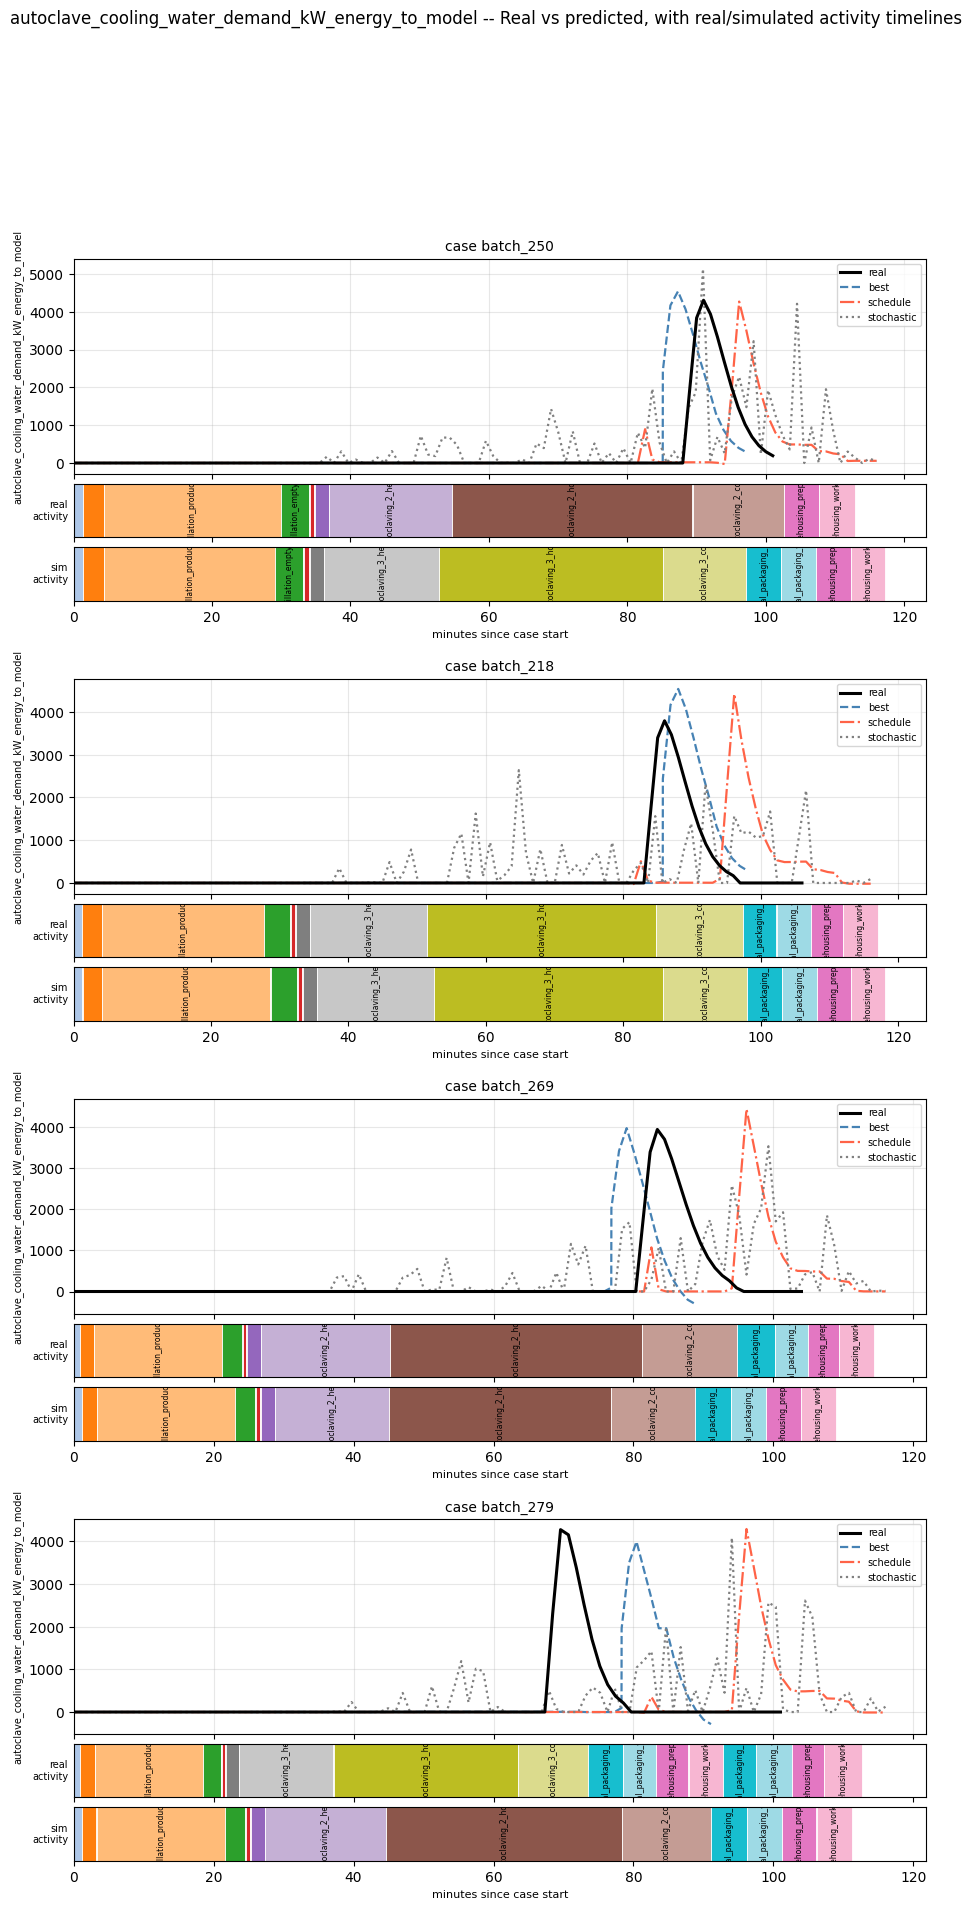

/tmp/ipykernel_337234/3001420789.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


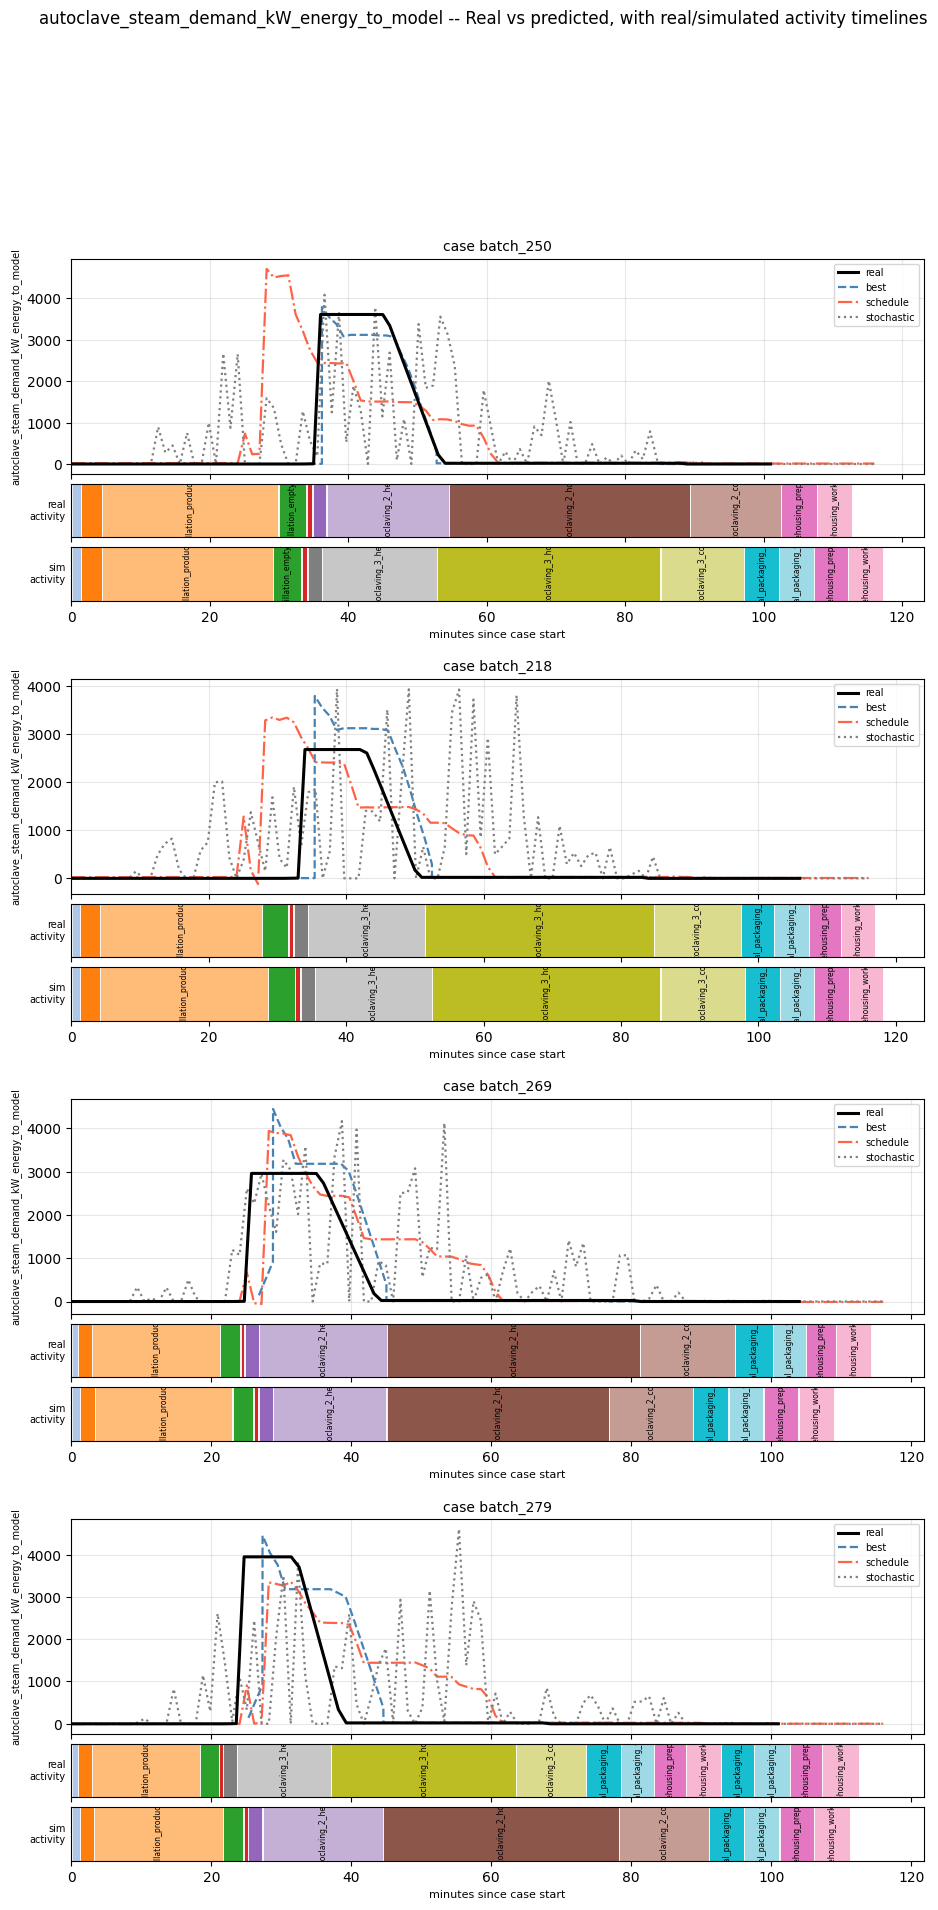

/tmp/ipykernel_337234/3001420789.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


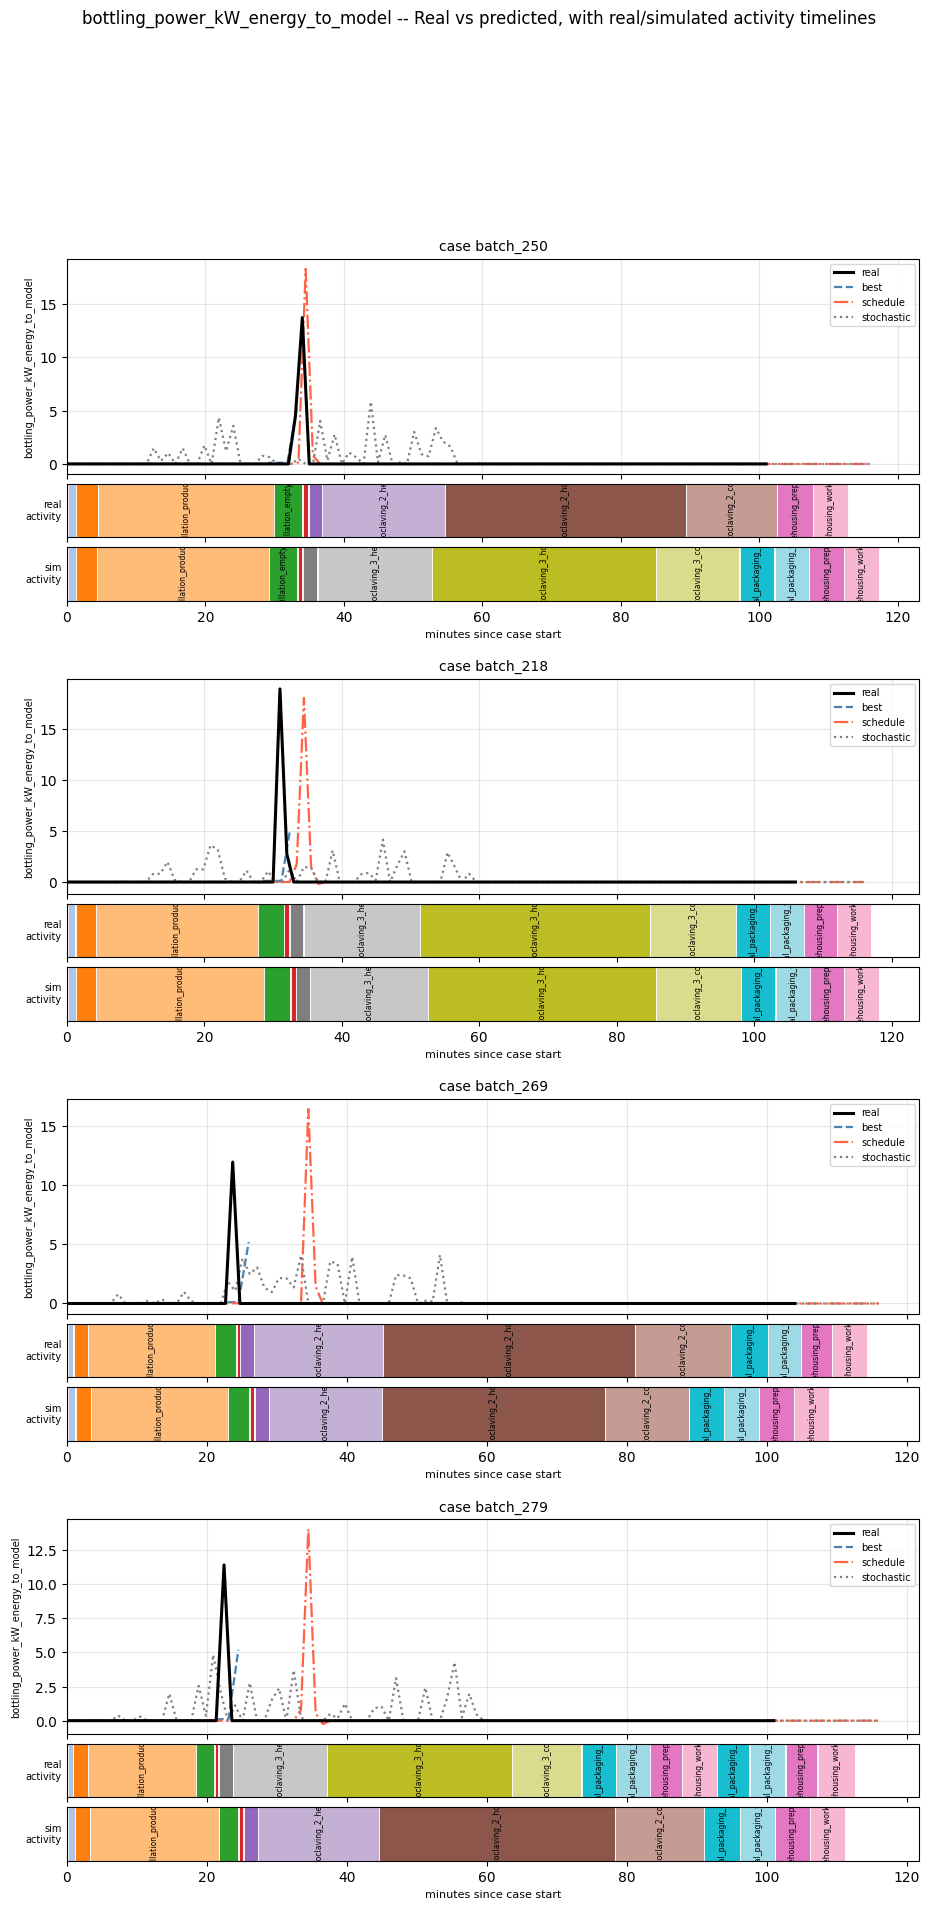

/tmp/ipykernel_337234/3001420789.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


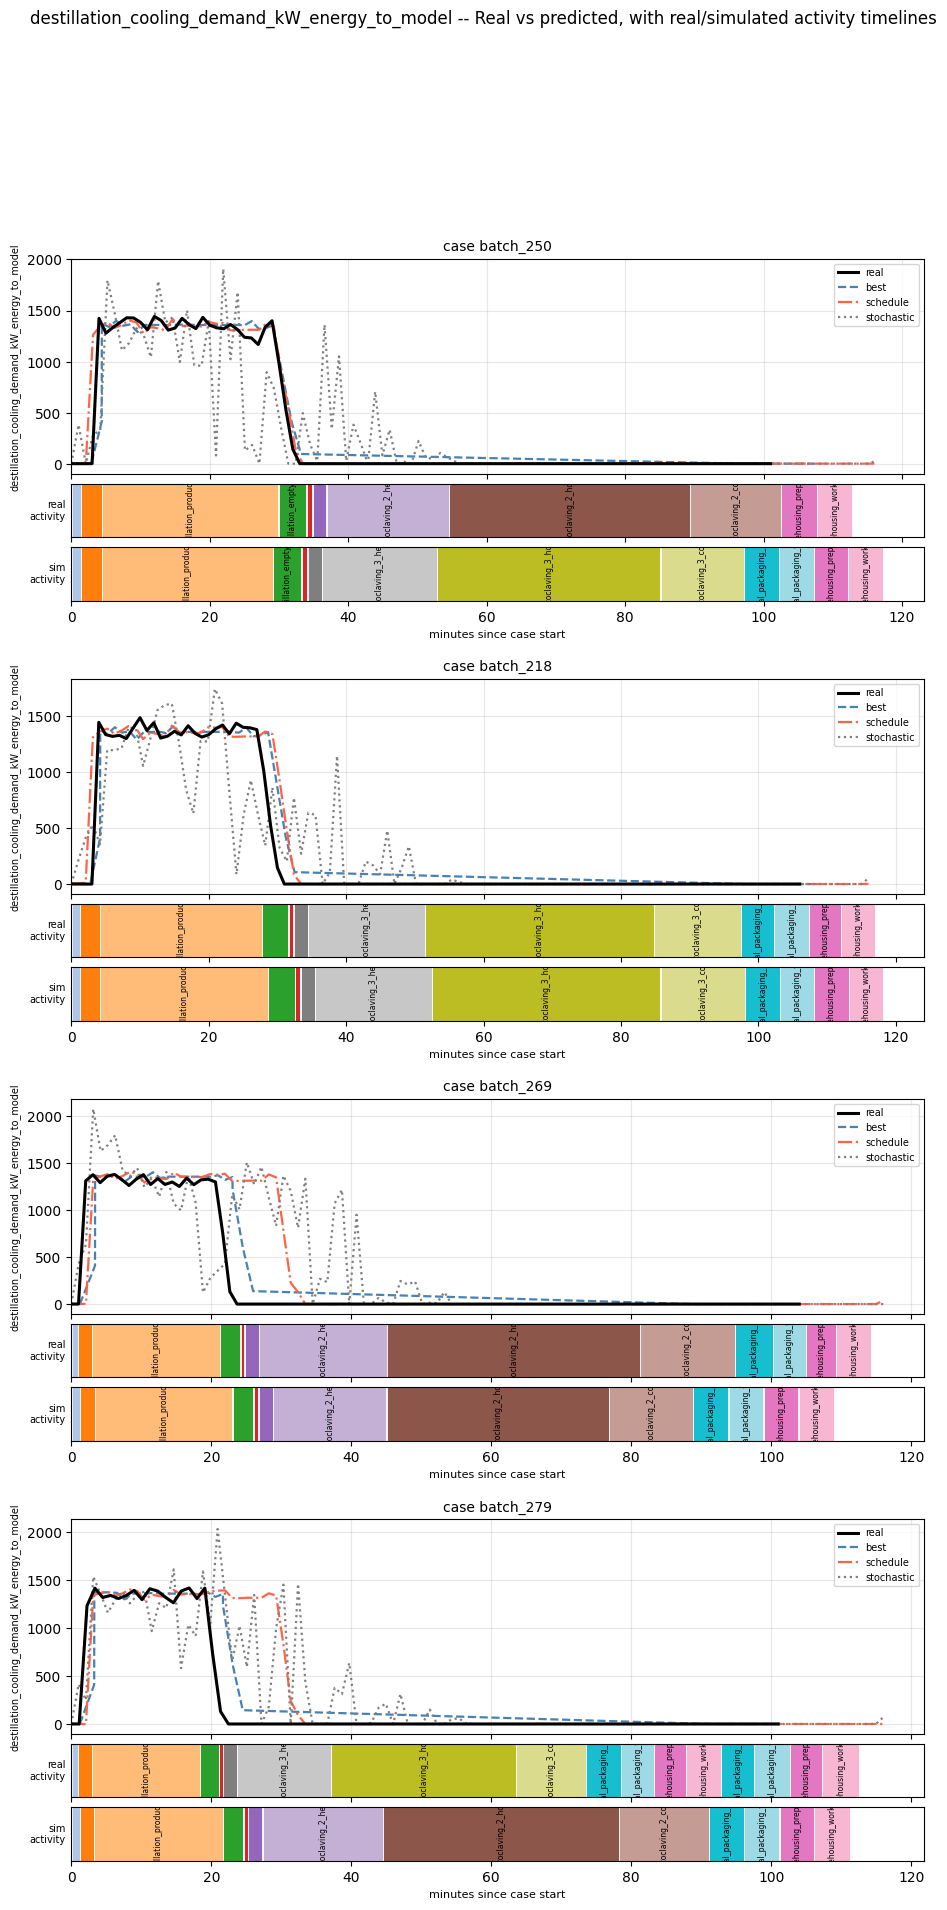

/tmp/ipykernel_337234/3001420789.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


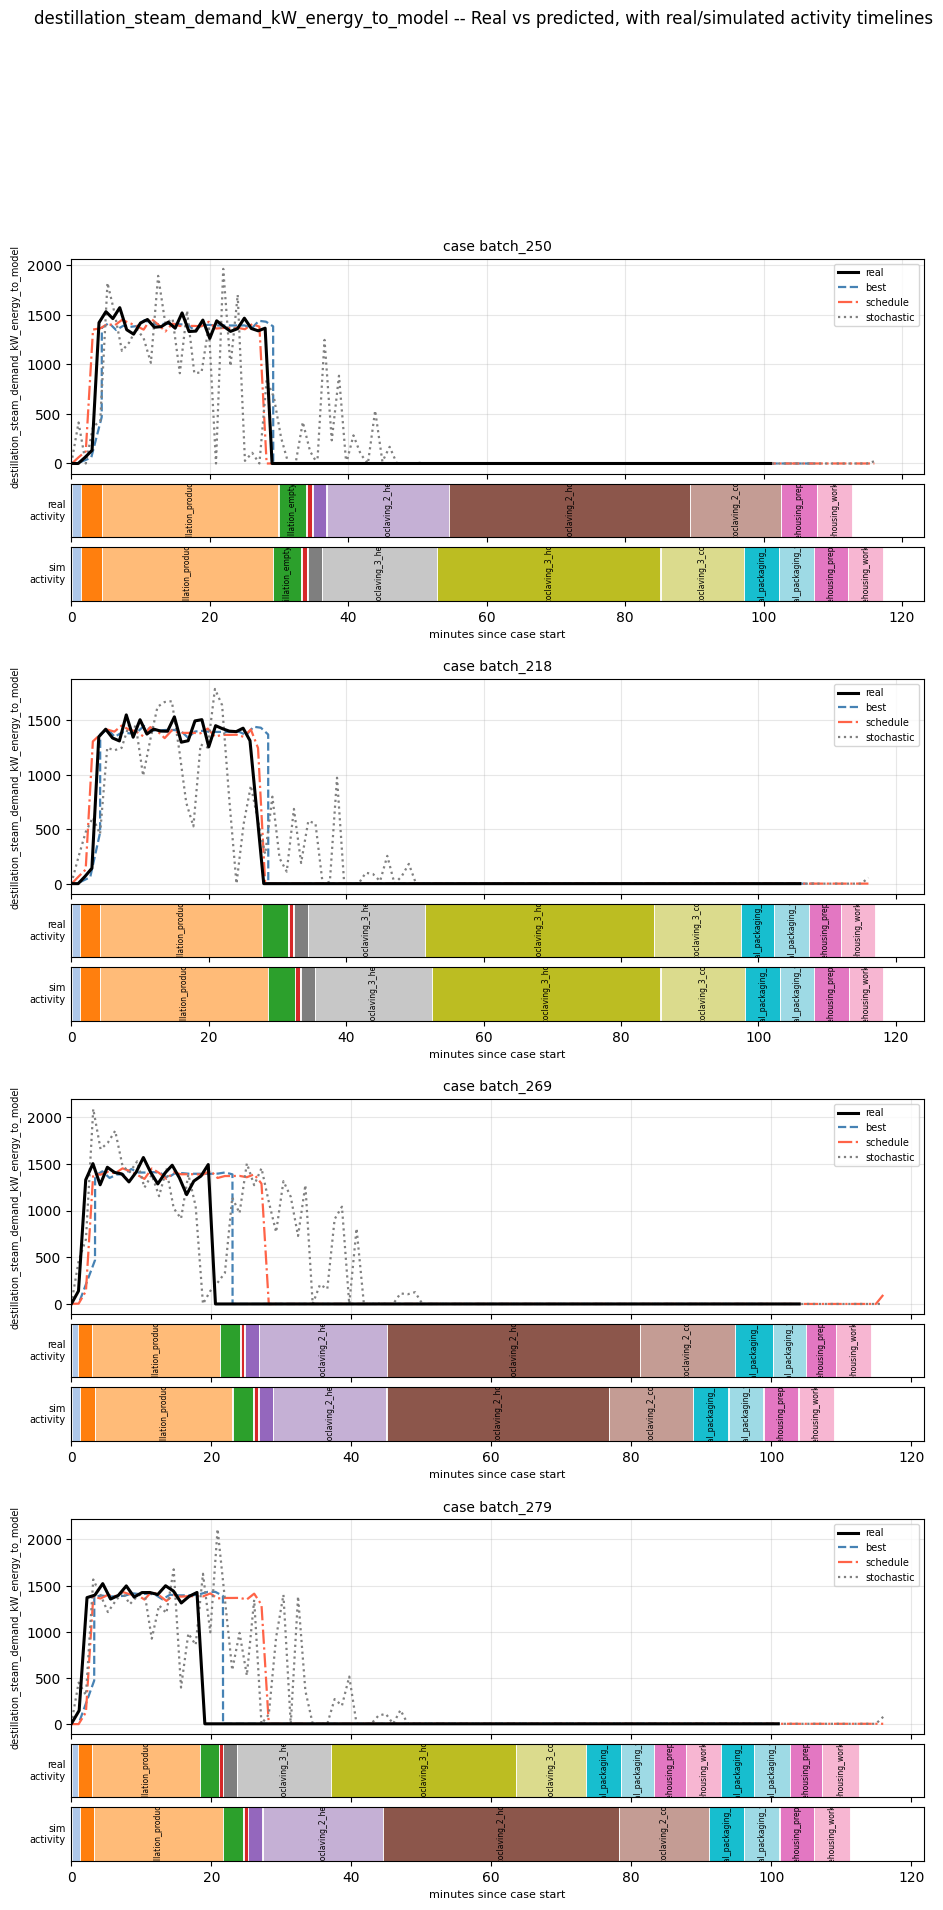

/tmp/ipykernel_337234/3001420789.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_curve.legend(fontsize=7, loc='upper right')


/tmp/ipykernel_337234/3001420789.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


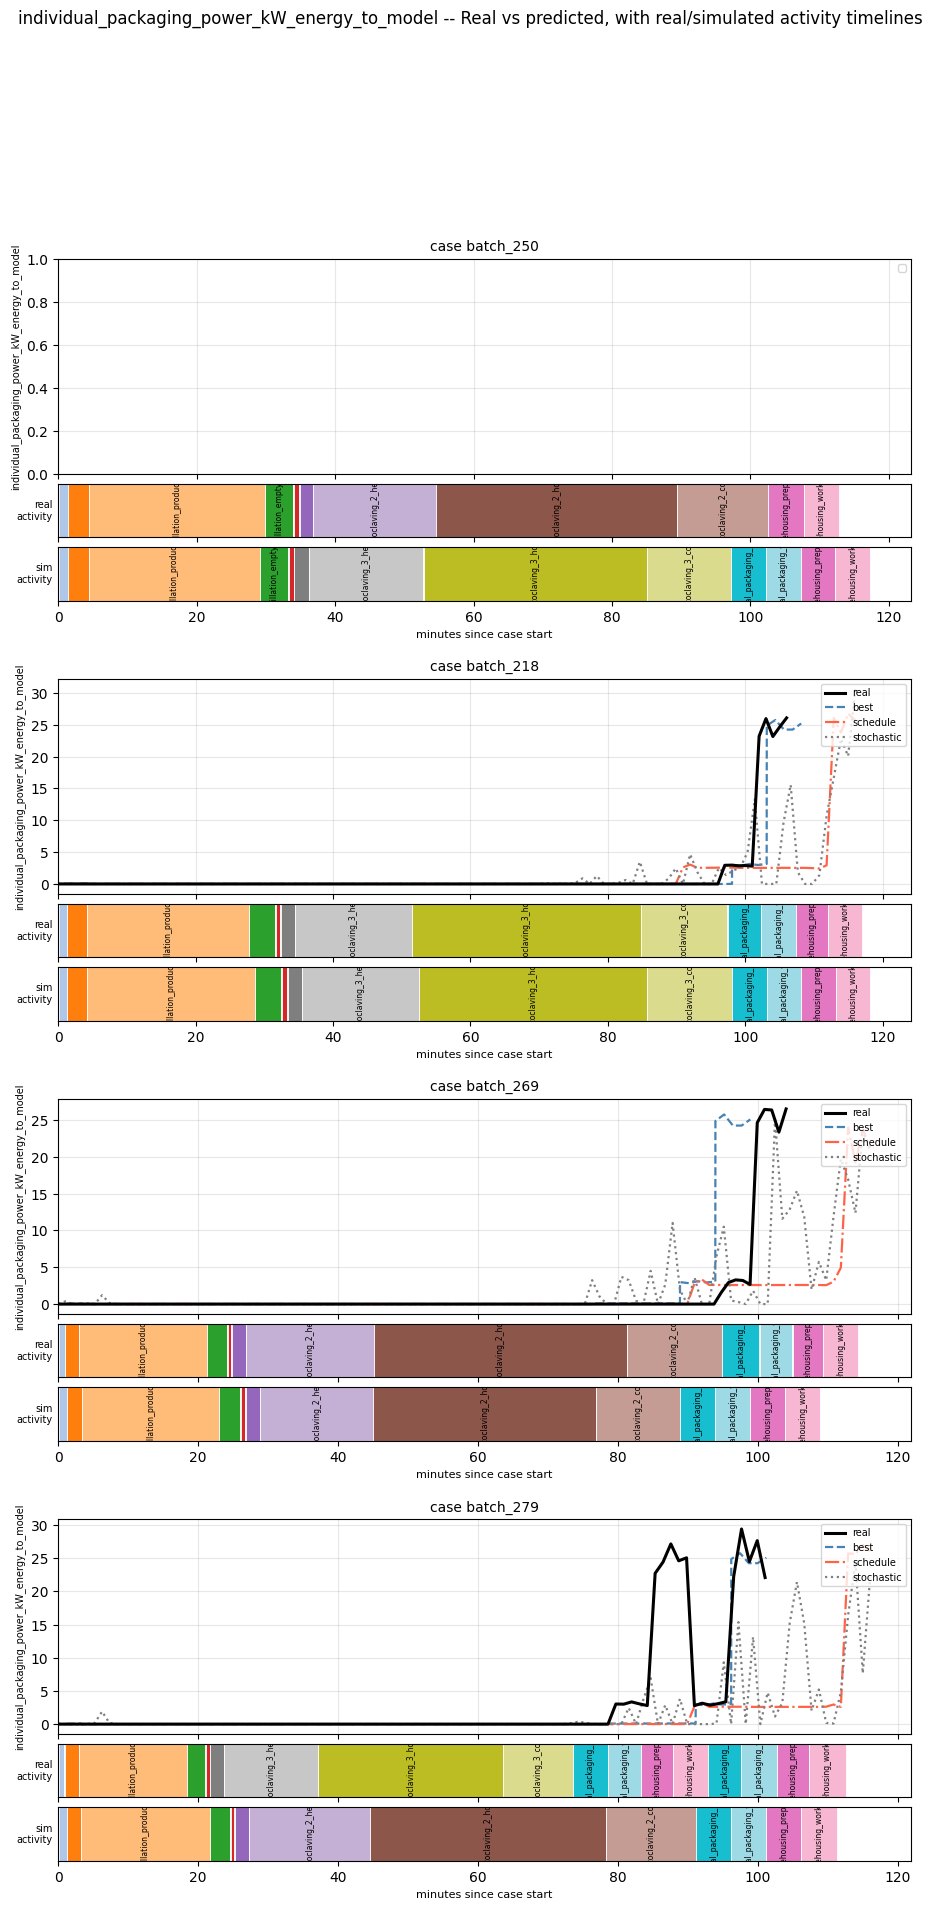

In [5]:
import matplotlib.cm as cm

_series_style = {
    'real':       dict(color='black',      linestyle='-',  linewidth=2.2, zorder=5),
    'best':       dict(color='steelblue',  linestyle='--', linewidth=1.6),
    'schedule':   dict(color='tomato',     linestyle='-.', linewidth=1.6),
    'stochastic': dict(color='gray',       linestyle=':',  linewidth=1.6),
}
_series_order = ['real', 'best', 'schedule', 'stochastic']

# Consistent color per exact activity name (shared across the real/simulated
# strips and across cases/sensors) -- a resource mismatch (e.g. real used
# autoclaving_2, simulated used autoclaving_1) then shows up directly as two
# DIFFERENT colors at roughly the same spot between the two strips, since
# 'autoclaving_2_hold' and 'autoclaving_1_hold' are different activity names.
_activity_color_map = {}
def _color_for_activity(act):
    if act not in _activity_color_map:
        _activity_color_map[act] = cm.tab20(len(_activity_color_map) % 20)
    return _activity_color_map[act]

def _draw_activity_strip(ax, timeline_df, min_label_width=4.0):
    if timeline_df is None or timeline_df.empty:
        ax.set_yticks([])
        return
    for _, row in timeline_df.iterrows():
        width = row['t_end_min'] - row['t_start_min']
        ax.barh(0, width, left=row['t_start_min'], height=1.0,
                color=_color_for_activity(row['activity']), edgecolor='white', linewidth=0.6)
        if width >= min_label_width:
            ax.text(row['t_start_min'] + width / 2, 0, row['activity'],
                    ha='center', va='center', fontsize=5.5, rotation=90, clip_on=True)
    ax.set_yticks([])
    ax.set_ylim(-0.5, 0.5)

for sensor in SENSORS:
    sub_sensor = df_curves[df_curves['sensor'] == sensor]
    _n = len(example_cases)
    # 3 rows per case (curve, real strip, sim strip) + a blank spacer row
    # between cases (not after the last one) so titles/tick labels don't
    # collide with the next case's block.
    _height_ratios = []
    _row_start = []
    for i in range(_n):
        _row_start.append(len(_height_ratios))
        _height_ratios += [4, 1, 1]
        if i < _n - 1:
            _height_ratios.append(1.1)
    fig = plt.figure(figsize=(11, 5.2 * _n))
    gs = fig.add_gridspec(len(_height_ratios), 1, height_ratios=_height_ratios, hspace=0.1)

    for i, cid in enumerate(example_cases):
        r0 = _row_start[i]
        ax_curve = fig.add_subplot(gs[r0])
        ax_real_strip = fig.add_subplot(gs[r0 + 1], sharex=ax_curve)
        ax_sim_strip  = fig.add_subplot(gs[r0 + 2], sharex=ax_curve)

        sub = sub_sensor[sub_sensor['case_id'] == cid]
        if sub.empty:
            ax_curve.set_title(f'case {cid} -- no data for this sensor')
        else:
            for series in _series_order:
                s = sub[sub['series'] == series].sort_values('t_minutes')
                if s.empty:
                    continue
                ax_curve.plot(s['t_minutes'], s['value'], label=series, **_series_style[series])
        ax_curve.set_title(f'case {cid}', fontsize=10)
        ax_curve.set_ylabel(sensor, fontsize=7)
        ax_curve.legend(fontsize=7, loc='upper right')
        ax_curve.grid(alpha=0.3)
        plt.setp(ax_curve.get_xticklabels(), visible=False)

        _real_tl = _activity_timeline(df_real_log, cid)
        _sim_tl  = _activity_timeline(df_sim_log, cid)
        _draw_activity_strip(ax_real_strip, _real_tl)
        _draw_activity_strip(ax_sim_strip, _sim_tl)
        ax_real_strip.set_ylabel('real\nactivity', rotation=0, ha='right', va='center', fontsize=7)
        ax_sim_strip.set_ylabel('sim\nactivity', rotation=0, ha='right', va='center', fontsize=7)
        plt.setp(ax_real_strip.get_xticklabels(), visible=False)
        ax_sim_strip.set_xlabel('minutes since case start', fontsize=8)

    fig.suptitle(f'{sensor} -- Real vs predicted, with real/simulated activity timelines', y=1.0)
    fig.tight_layout()
    plt.show()


## Activities executed, per example case (real vs. best-fidelity simulated)

The curve plots above only show sensor values -- they don't explain *why* a curve
starts/stops where it does, or why "best" often only covers a narrow window (see
`predict_curve_for_instance`: it returns nothing for any `(sensor, activity, object)`
combo without a trained pipeline, so "best"'s predicted curve simply has gaps rather
than explicit zeros).

This section prints the actual activity timeline for each example case -- both the
real one and the simulated one from this process's best-fidelity mode (lowest
`test_overall_error`) -- in minutes since case start, so you can line up any curve
segment with exactly which activity produced it. Watch in particular for the
simulated log picking a **different object/resource** than the real case (e.g. a
different autoclave unit) for the same activity type -- when that happens, "best"'s
prediction is for a physically different piece of equipment than what the real
sensor reading came from, which explains a lot more than a timing offset would.


In [6]:
# -- Exact values behind the activity strips above, plus explicit resource-mismatch flags --
import re

_resource_re = re.compile(r'^([a-zA-Z_]+?_(\d+))_')

def _resource_variants(activities):
    variants = {}
    for act in activities:
        m = _resource_re.match(act)
        if m:
            family = m.group(1).rsplit('_', 1)[0]  # e.g. 'autoclaving' from 'autoclaving_2'
            variants.setdefault(family, set()).add(m.group(2))
    return variants


for cid in example_cases:
    print(f'\n{"="*70}\ncase {cid}\n{"="*70}')
    print('--- REAL activities ---')
    _real_tl = _activity_timeline(df_real_log, cid)
    display(_real_tl.round(2))
    print(f'--- SIMULATED activities ({best_mode}) ---')
    _sim_tl = _activity_timeline(df_sim_log, cid)
    display(_sim_tl.round(2))

    _real_variants = _resource_variants(_real_tl['activity'])
    _sim_variants  = _resource_variants(_sim_tl['activity'])
    _families = sorted(set(_real_variants) | set(_sim_variants))
    _reported = False
    for fam in _families:
        r_v, s_v = _real_variants.get(fam, set()), _sim_variants.get(fam, set())
        if r_v and s_v and r_v != s_v:
            if not _reported:
                print('  RESOURCE MISMATCH (real vs. simulated picked a different unit):')
                _reported = True
            print(f'    {fam}: real used {sorted(r_v)}  vs  simulated used {sorted(s_v)}')
    if not _reported:
        print('  (no resource-unit mismatch detected for this case)')



case batch_250
--- REAL activities ---


,activity,object,t_start_min,t_end_min
0,water_supply_prepare,water_supply,0.00,0.10
1,water_supply_working,water_supply,0.12,1.35
2,destillation_preparation,destillation,1.36,4.45
3,destillation_production,destillation,4.47,29.92
4,destillation_emptying,destillation,29.94,33.96
5,bottling_prepare,bottling,33.98,34.08
6,bottling_working,bottling,34.10,34.77
7,bottling_cool,bottling,34.79,34.89
8,autoclaving_2_prepare,autoclaving_2,34.91,36.85
9,autoclaving_2_heat,autoclaving_2,36.87,54.60


--- SIMULATED activities (petri_net_heuristic_ml_plus_per_act) ---


,activity,object,t_start_min,t_end_min
0,water_supply_prepare,sterilization_process,0.00,0.10
1,water_supply_working,sterilization_process,0.12,1.35
2,destillation_preparation,sterilization_process,1.37,4.39
3,destillation_production,sterilization_process,4.41,29.15
4,destillation_emptying,sterilization_process,29.17,33.18
5,bottling_prepare,sterilization_process,33.20,33.30
6,bottling_working,sterilization_process,33.32,33.99
7,bottling_cool,sterilization_process,34.01,34.11
8,autoclaving_3_prepare,sterilization_process,34.13,36.19
9,autoclaving_3_heat,sterilization_process,36.21,52.76


  RESOURCE MISMATCH (real vs. simulated picked a different unit):
    autoclaving: real used ['2']  vs  simulated used ['3']

case batch_218
--- REAL activities ---


...

  (no resource-unit mismatch detected for this case)

case batch_279
--- REAL activities ---


,activity,object,t_start_min,t_end_min
0,water_supply_prepare,water_supply,0.00,0.07
1,water_supply_working,water_supply,0.08,0.89
2,destillation_preparation,destillation,0.91,3.00
3,destillation_production,destillation,3.02,18.44
4,destillation_emptying,destillation,18.46,21.04
5,bottling_prepare,bottling,21.06,21.13
6,bottling_working,bottling,21.14,21.63
7,bottling_cool,bottling,21.64,21.71
8,autoclaving_3_prepare,autoclaving_3,21.73,23.66
9,autoclaving_3_heat,autoclaving_3,23.68,37.13


--- SIMULATED activities (petri_net_heuristic_ml_plus_per_act) ---


,activity,object,t_start_min,t_end_min
0,water_supply_prepare,sterilization_process,0.00,0.10
1,water_supply_working,sterilization_process,0.12,1.20
2,destillation_preparation,sterilization_process,1.22,3.27
3,destillation_production,sterilization_process,3.29,21.66
4,destillation_emptying,sterilization_process,21.68,24.49
5,bottling_prepare,sterilization_process,24.51,24.61
6,bottling_working,sterilization_process,24.63,25.18
7,bottling_cool,sterilization_process,25.19,25.29
8,autoclaving_2_prepare,sterilization_process,25.31,27.31
9,autoclaving_2_heat,sterilization_process,27.32,44.58


  RESOURCE MISMATCH (real vs. simulated picked a different unit):
    autoclaving: real used ['3']  vs  simulated used ['2']


## Aggregated comparison: Schedule-direct vs. Best, mine vs. Stochastic generator

One standardized number per method, across all sensors for this process. The raw
`schedule_wasserstein_time`/`_value`, `stochastic_wasserstein_time`/`_value`,
`best_wasserstein_time`/`_value` columns in `schedule_profile_eval_summary.csv` are in
minutes / raw sensor units respectively -- not comparable across sensors of different
units (kW vs kg/h vs °C). Standardized here the same way as the Complete-Curve section
in `results_latex_table.ipynb`:

- `W1 (time), rel.` = `*_wasserstein_time` / real median case duration (minutes) for this process.
- `W1 (value), rel.` = `*_wasserstein_value` / real per-case-mean median for that sensor.

Both are then unitless, so a single median across sensors -- and even across *both*
metrics pooled together for the "Combined" column -- is a fair comparison.


In [7]:
# -- Load precomputed per-sensor W1 medians for this process (schedule/stochastic/best) --
_sp_summary_path = run_dir / 'schedule_profile_eval_results' / PROCESS / 'schedule_profile_eval_summary.csv'
assert _sp_summary_path.exists(), f'Missing {_sp_summary_path}'
df_sp_summary = pd.read_csv(_sp_summary_path)
print(f'{len(df_sp_summary)} sensor rows for {PROCESS}')
display(df_sp_summary)


7 sensor rows for process_1


,sensor,schedule_wasserstein_time,schedule_wasserstein_value,stochastic_wasserstein_time,stochastic_wasserstein_value,best_wasserstein_time,best_wasserstein_value,n_cases,process
0,autoclave_cooling_water_demand_kW_energy_to_model,15.527660,91.574219,16.661474,228.030173,10.260737,141.955022,90,process_1
1,autoclave_steam_demand_kW_energy_to_model,14.143601,283.705165,15.626578,349.749638,3.885573,357.348201,90,process_1
2,bottling_power_kW_energy_to_model,12.100806,0.060497,13.841048,0.461411,1.967958,0.223363,90,process_1
3,destillation_cooling_demand_kW_energy_to_model,6.355297,92.127409,6.083082,120.999600,1.471183,553.155929,90,process_1
4,destillation_steam_demand_kW_energy_to_model,5.704164,85.180295,5.674047,117.877453,1.578280,529.403598,90,process_1
5,individual_packaging_power_kW_energy_to_model,17.301156,0.800169,17.712408,1.147528,19.808732,0.973289,79,process_1
6,water_supply_power_kW_energy_to_model,0.472350,0.012442,0.553105,0.030470,NaN,NaN,90,process_1


In [8]:
# -- Standardization references: real median case duration + real per-case-mean median per sensor --
_case_duration_min = {}
_test_log_path = run_dir / 'predicted_logs' / f'{PROCESS}_test_set.parquet'
if _test_log_path.exists():
    _tl = pd.read_parquet(_test_log_path, columns=['case_id', 'timestamp_start', 'timestamp_end'])
    _tl['timestamp_start'] = pd.to_datetime(_tl['timestamp_start'])
    _tl['timestamp_end'] = pd.to_datetime(_tl['timestamp_end'])
    _case_ends = _tl.groupby('case_id')['timestamp_end'].max()
    _case_starts = _tl.groupby('case_id')['timestamp_start'].min()
    _durations = (_case_ends - _case_starts).dt.total_seconds() / 60.0
    case_duration_median_min = float(_durations.median())
else:
    case_duration_median_min = float('nan')
print(f'Real median case duration for {PROCESS}: {case_duration_median_min:.2f} min')

real_value_median = {}
_edist_dir = run_dir / 'energy_distribution_results' / PROCESS
if _edist_dir.exists():
    for _mode_dir in sorted(_edist_dir.iterdir()):
        _csv_path = _mode_dir / 'per_case_sensor_mean.csv'
        if not _csv_path.exists():
            continue
        _pdf = pd.read_csv(_csv_path)
        for _, _r in _pdf.iterrows():
            real_value_median.setdefault(_r['sensor'], _r['real_median'])
print(f'Real per-case-mean median available for {len(real_value_median)} sensors')


Real median case duration for process_1: 130.73 min
Real per-case-mean median available for 7 sensors


In [9]:
# -- Standardize, then aggregate (median across sensors, and across both metrics for Combined) --
_methods = {
    'Schedule-direct':      ('schedule_wasserstein_time',   'schedule_wasserstein_value'),
    'Best, mine':           ('best_wasserstein_time',        'best_wasserstein_value'),
    'Stochastic generator': ('stochastic_wasserstein_time', 'stochastic_wasserstein_value'),
}

_rows = []
for _, r in df_sp_summary.iterrows():
    sensor = r['sensor']
    rvm = real_value_median.get(sensor)
    for method, (tcol, vcol) in _methods.items():
        t_raw = r.get(tcol)
        v_raw = r.get(vcol)
        t_rel = t_raw / case_duration_median_min if pd.notna(t_raw) and case_duration_median_min else float('nan')
        v_rel = v_raw / abs(rvm) if pd.notna(v_raw) and rvm not in (None, 0) and not pd.isna(rvm) else float('nan')
        _rows.append({'sensor': sensor, 'method': method, 'w1_time_rel': t_rel, 'w1_value_rel': v_rel})

df_sp_relative = pd.DataFrame(_rows)

_agg = df_sp_relative.groupby('method').agg(
    **{'W1 (time), rel. median': ('w1_time_rel', 'median'),
       'W1 (value), rel. median': ('w1_value_rel', 'median')}
)

# Combined: pool both metrics' values together per method, then one median --
# valid only because both are already unitless (relative) versions.
_pooled = pd.concat([
    df_sp_relative[['method', 'w1_time_rel']].rename(columns={'w1_time_rel': 'v'}),
    df_sp_relative[['method', 'w1_value_rel']].rename(columns={'w1_value_rel': 'v'}),
], ignore_index=True)
_agg['Combined, rel. median'] = _pooled.groupby('method')['v'].median()

_agg = _agg.sort_values('Combined, rel. median')

_str_table = _agg.round(3).astype(object)
for col in _agg.columns:
    vals = _agg[col].dropna()
    if vals.empty:
        continue
    best_val = vals.min()
    for idx in _agg.index:
        val = _agg.loc[idx, col]
        if pd.isna(val):
            _str_table.loc[idx, col] = ''
            continue
        fmt = f'{val:.3f}'
        _str_table.loc[idx, col] = (r'\textbf{' + fmt + r'}') if abs(val - best_val) < 1e-6 else fmt

latex = _str_table.to_latex(
    escape=False, column_format='l|c|c|c',
    caption=(
        f'Aggregated Schedule Profile Evaluation for {PROCESS}, run {run_dir.name}. '
        r'One standardized (scale-free) number per method, median over sensors '
        r'(Combined: median over sensors and both metrics pooled together). '
        r'Lower is better. Rows sorted best-to-worst by Combined. \textbf{Bold} = best method per column.'
    ),
    label=f'tab:schedule_profile_agg_{PROCESS}',
    position='H',
)
print(latex.replace('_', r'\_'))
display(_agg.round(3))


\begin{table}[H]
\caption{Aggregated Schedule Profile Evaluation for process\_1, run experiment\_905\_20260713\_190136. One standardized (scale-free) number per method, median over sensors (Combined: median over sensors and both metrics pooled together). Lower is better. Rows sorted best-to-worst by Combined. \textbf{Bold} = best method per column.}
\label{tab:schedule\_profile\_agg\_process\_1}
\begin{tabular}{l|c|c|c}
\toprule
 & W1 (time), rel. median & W1 (value), rel. median & Combined, rel. median \\
method &  &  &  \\
\midrule
Schedule-direct & 0.093 & \textbf{0.489} & \textbf{0.113} \\
Stochastic generator & 0.106 & 0.692 & 0.131 \\
Best, mine & \textbf{0.022} & 1.050 & 0.140 \\
\bottomrule
\end{tabular}
\end{table}



,"W1 (time), rel. median","W1 (value), rel. median","Combined, rel. median"
method,,,
Schedule-direct,0.093,0.489,0.113
Stochastic generator,0.106,0.692,0.131
"Best, mine",0.022,1.050,0.140
